# Truck Delay Prediction - Exploratory Data Analysis

## Objectives

This notebook explores the engineered truck shipment dataset to:

- Understand the dataset structure
- Assess data quality
- Explore feature distributions
- Investigate relationships with shipment delays
- Generate business insights
- Validate engineered features before model development


In [67]:
import sys
from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd().parent

# Add src folder to Python path
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

print("Project Root:", PROJECT_ROOT)
print("Source Path :", SRC_PATH)


Project Root: c:\Users\Admin\Desktop\Delayed Truck Shipment\truck_delay_pipeline
Source Path : c:\Users\Admin\Desktop\Delayed Truck Shipment\truck_delay_pipeline\src


In [68]:
# imports
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from feature_engineering import build_final_dataset
from train_model import time_based_split, scale_features, evaluate
from sklearn.ensemble import RandomForestClassifier

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

# Consistent dashboard color palette used across every multi-panel figure below
PALETTE = {"on_time": "#4C72B0", "delayed": "#DD8452", "accent": "#55A868"}


In [69]:
# load build_final_dataset
full_df, model_df = build_final_dataset()

print("Full Dataset :", full_df.shape)
print("Model Dataset:", model_df.shape)


Full Dataset : (12308, 48)
Model Dataset: (12308, 40)


In [70]:
# NOTE: in Jupyter, only the LAST expression in a cell auto-displays.
# The original draft had .head() and .describe().T in the same cell as
# .info() -- .info() prints directly so it showed, but .head() was silently
# dropped. Splitting these (or using display()) makes sure every output
# is actually visible.
display(full_df.head())
full_df.info()


,truck_id,route_id,departure_date,estimated_arrival,delay,origin_id,destination_id,distance,average_hours,no_of_vehicles,accident,temp,wind_speed,precip,humidity,visibility,pressure,origin_temp,origin_wind_speed,origin_precip,origin_humidity,origin_visibility,origin_pressure,destination_temp,destination_wind_speed,destination_precip,destination_humidity,destination_visibility,destination_pressure,driver_id,name,gender,age,experience,driving_style,ratings,average_speed_mph,truck_age,load_capacity_pounds,mileage_mpg,fuel_type,route_bad_weather,origin_bad_weather,destination_bad_weather,any_bad_weather,high_traffic,departure_day_of_week,is_weekend_departure
0,30312694,R-b236e347,2019-01-01 07:00:00,2019-01-01 13:13:12.000000000,0,C-927ceb5e,C-d80a1e7d,310.75,6.22,2240.428571,0,23.000000,4.000000,0.000000,76.000000,6.000000,1011.000000,27,12,0.0,83,4,1027,41,11,0.0,76,6,1025,94ed3e6d-f,Manuel Wise,male,48,9,proactive,7,57.36,9,3000.0,23,diesel,0,0,0,0,1,1,0
1,59856374,R-29ea762e,2019-01-01 07:00:00,2019-01-02 04:01:12.000000000,0,C-927ceb5e,C-639c5e36,1050.84,21.02,1837.272727,1,50.666667,7.666667,0.000000,76.666667,6.000000,1018.666667,27,12,0.0,83,4,1027,3,3,0.0,71,6,1037,0efc20ea-5,Steven Bishop,male,47,12,proactive,8,57.04,7,15000.0,21,diesel,0,0,0,0,0,1,0
2,12602955,R-a3d67783,2019-01-01 07:00:00,2019-01-01 07:45:36.000000000,0,C-927ceb5e,C-a9f2c329,38.10,0.76,1966.000000,0,29.685083,6.762431,0.006077,73.209945,4.486188,1019.027624,27,12,0.0,83,4,1027,28,10,0.0,84,3,1027,8b5ca0fd-7,Nathan Baker,male,43,6,proactive,8,64.11,10,3000.0,26,diesel,1,0,0,1,0,1,0
3,46619422,R-31ec9310,2019-01-01 07:00:00,2019-01-01 20:46:48.000000000,0,C-927ceb5e,C-c7cacd1d,688.91,13.78,2225.571429,0,52.000000,2.500000,0.000000,78.000000,6.000000,1012.000000,27,12,0.0,83,4,1027,27,11,0.0,67,6,1026,4d8521f5-6,Andrew Thompson,male,49,16,conservative,4,49.47,12,6000.0,27,diesel,0,0,0,0,1,1,0
4,10140178,R-a07c5dbd,2019-01-01 07:00:00,2019-01-01 21:34:11.999999999,0,C-927ceb5e,C-ef47bdcd,728.40,14.57,2206.800000,1,-4.000000,2.000000,0.000000,100.000000,5.000000,1020.000000,27,12,0.0,83,4,1027,10,6,0.0,75,6,1029,d809c9ce-3,Joel Phillips,male,56,22,conservative,9,43.42,12,3000.0,23,diesel,0,0,0,0,0,1,0


<class 'pandas.DataFrame'>
RangeIndex: 12308 entries, 0 to 12307
Data columns (total 48 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   truck_id                 12308 non-null  int64         
 1   route_id                 12308 non-null  str           
 2   departure_date           12308 non-null  datetime64[ns]
 3   estimated_arrival        12308 non-null  datetime64[ns]
 4   delay                    12308 non-null  int64         
 5   origin_id                12308 non-null  str           
 6   destination_id           12308 non-null  str           
 7   distance                 12308 non-null  float64       
 8   average_hours            12308 non-null  float64       
 9   no_of_vehicles           12308 non-null  float64       
 10  accident                 12308 non-null  int64         
 11  temp                     12308 non-null  float64       
 12  wind_speed               12308 non-null  fl

In [71]:
full_df.describe().T


,count,mean,min,25%,50%,75%,max,std
truck_id,12308.0,32911348.819548,10008392.0,18443612.0,26114011.0,33250272.0,99981667.0,22212871.114155
departure_date,12308,2019-01-21 17:37:31.023724544,2019-01-01 07:00:00,2019-01-10 07:00:00,2019-01-22 07:00:00,2019-02-02 07:00:00,2019-02-12 07:00:00,NaN
estimated_arrival,12308,2019-01-22 18:25:07.083197952,2019-01-01 07:04:48,2019-01-11 00:08:06,2019-01-22 15:58:12,2019-02-03 13:51:18,2019-02-14 16:06:00,NaN
delay,12308.0,0.348879,0.0,0.0,0.0,1.0,1.0,0.476635
distance,12308.0,1239.662909,3.9,414.27,755.21,1185.3,10055.01,1681.30652
average_hours,12308.0,24.79335,0.08,8.29,15.1,23.71,201.1,33.626063
no_of_vehicles,12308.0,1824.243773,135.0,1663.727273,1934.408964,2211.0,3061.0,533.478608
accident,12308.0,0.570686,0.0,0.0,1.0,1.0,1.0,0.494998
temp,12308.0,57.340938,-6.0,46.044199,58.21547,68.5,109.0,16.027381
wind_speed,12308.0,8.084105,0.0,5.666667,7.6,10.0,30.5,3.665864


# Observations

- The merged dataset contains 12,308 truck trips described by 48 variables.
- All variables have complete records, indicating that preprocessing successfully handled missing values.
- The dataset includes numerical, categorical, and datetime features, providing rich information for predictive modelling.
- Several engineered features, including traffic, weather, and temporal indicators, were created to better capture factors associated with shipment delays.
- Distance and average travel time span a wide range, suggesting a mix of short regional hauls and longer routes in the data.


In [72]:
# Missing values and duplicates check
missing = (
    full_df
    .isnull()
    .sum()
    .sort_values(ascending=False)
)
missing = missing[missing > 0]

duplicates = full_df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")
print(f"Columns with missing values: {len(missing)}")
if len(missing):
    display(missing)
else:
    print("No missing values in any column.")


Duplicate rows: 0
Columns with missing values: 0
No missing values in any column.


## Target Analysis (dashboard)

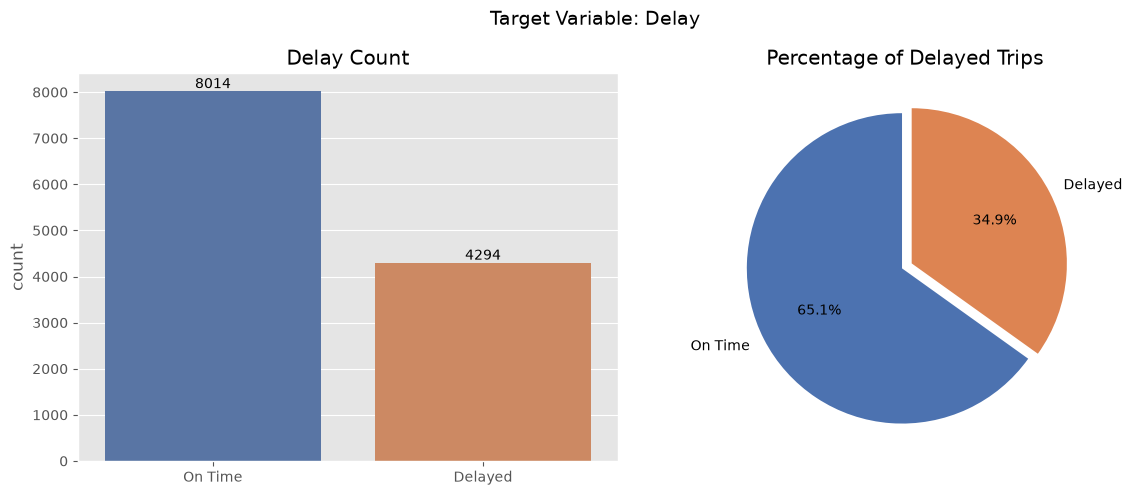

delay
0    8014
1    4294
Name: count, dtype: int64


In [73]:
# Dashboard: count + percentage share of the target in a single figure,
# so the two views can be compared side-by-side instead of scrolling
# between two separate plots.
delay_counts = full_df["delay"].value_counts().sort_index()
labels = ["On Time", "Delayed"]
colors = [PALETTE["on_time"], PALETTE["delayed"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x="delay", data=full_df, palette=colors, ax=axes[0])
axes[0].set_xticklabels(labels)
axes[0].set_title("Delay Count")
axes[0].set_xlabel("")
for container in axes[0].containers:
    axes[0].bar_label(container)

axes[1].pie(
    delay_counts,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    explode=(0.02, 0.05),
)
axes[1].set_title("Percentage of Delayed Trips")

plt.suptitle("Target Variable: Delay", fontsize=14)
plt.tight_layout()
plt.show()

print(delay_counts)


### Observations

- The target variable is moderately balanced, with 65.1% on-time trips and 34.9% delayed trips.
- Delayed shipments constitute a significant proportion of the data, making delay prediction an important operational problem.
- Since the classes are reasonably balanced, no resampling techniques (such as SMOTE or undersampling) are required at this stage.
- The distribution provides sufficient positive examples for training classification models.


## Numerical Feature Distributions (dashboard)

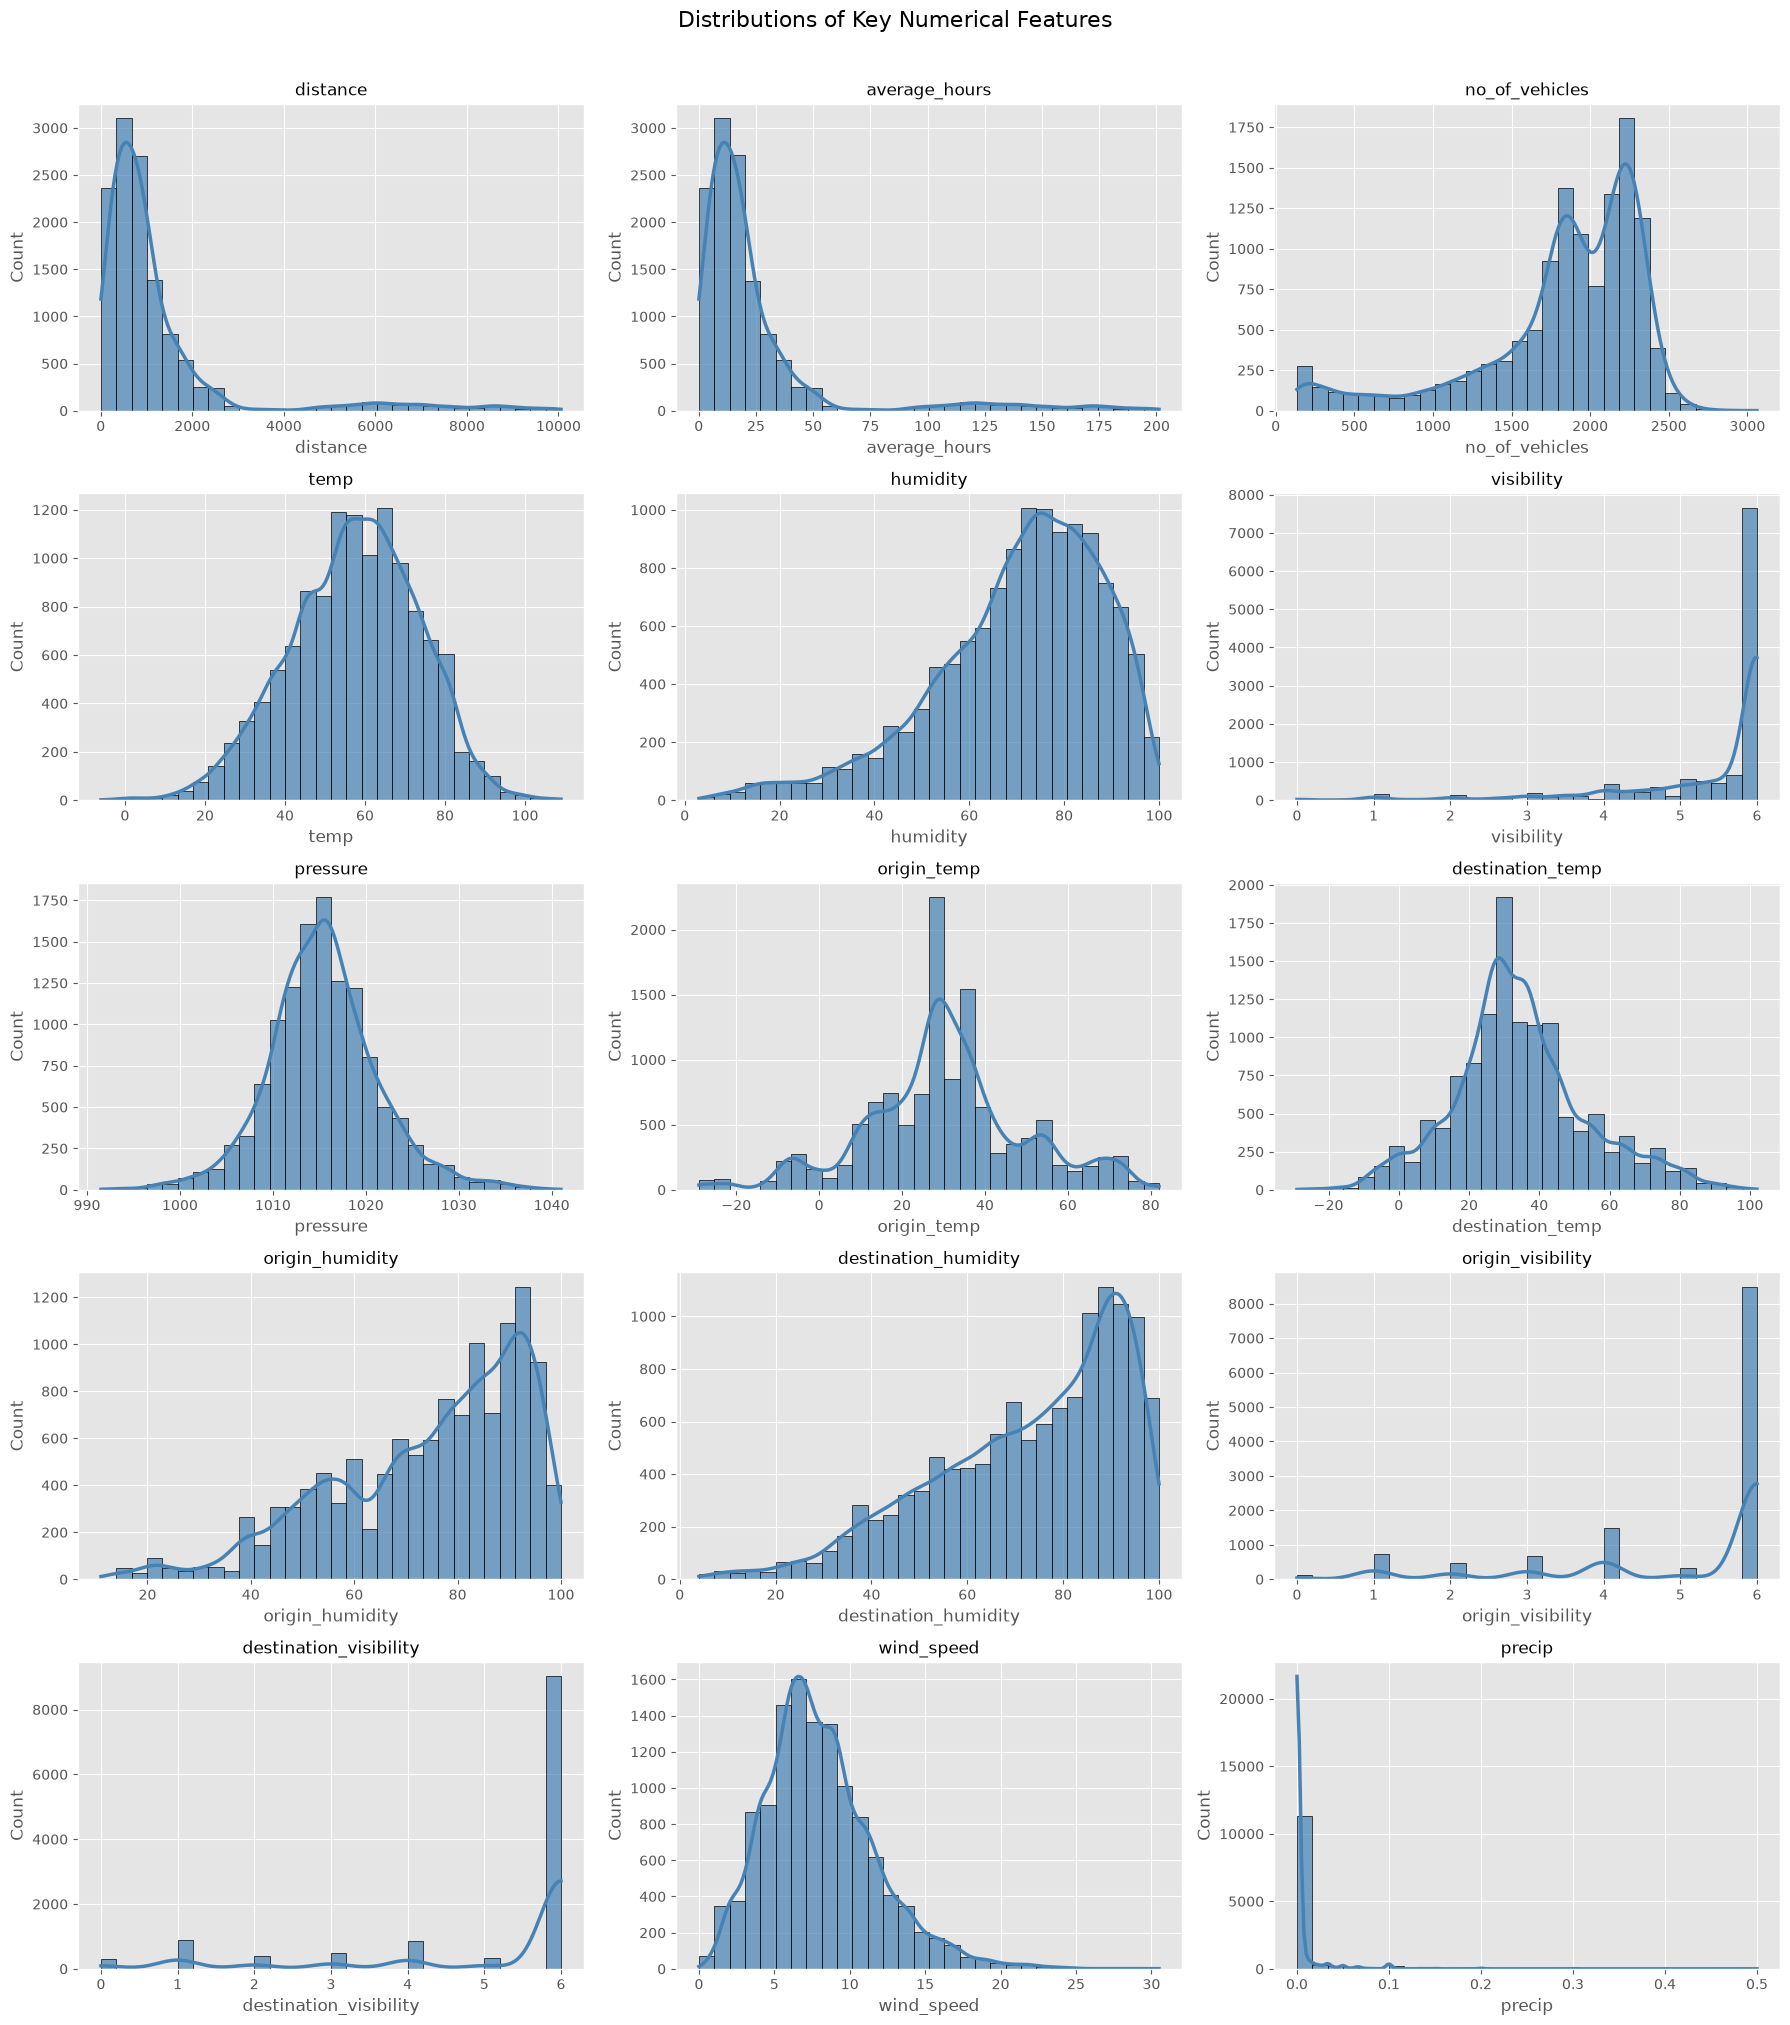

In [74]:
important_features = [
    "distance", "average_hours", "no_of_vehicles", "temp", "humidity",
    "visibility", "pressure", "origin_temp", "destination_temp",
    "origin_humidity", "destination_humidity", "origin_visibility",
    "destination_visibility", "wind_speed", "precip",
]

fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()

for ax, feature in zip(axes, important_features):
    sns.histplot(
        data=full_df,
        x=feature,
        bins=30,
        kde=True,
        ax=ax,
        color="steelblue",
        edgecolor="black",
        alpha=0.7,
        line_kws={"color": "crimson", "linewidth": 2.5},
    )
    ax.set_title(feature, fontsize=12)
    ax.set_xlabel(feature)  # was an incomplete statement in the draft (no-op) -- fixed

plt.suptitle("Distributions of Key Numerical Features", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


## Observations

- Distance and average travel time are highly right-skewed, indicating that most truck trips are relatively short while only a few involve long-haul routes.
- Traffic volume exhibits multiple peaks, suggesting the presence of distinct traffic conditions rather than a continuous distribution.
- Temperature and atmospheric pressure are approximately normally distributed.
- Visibility is heavily concentrated at its maximum value, indicating that poor visibility conditions are relatively rare in this dataset.


## Correlation Matrix

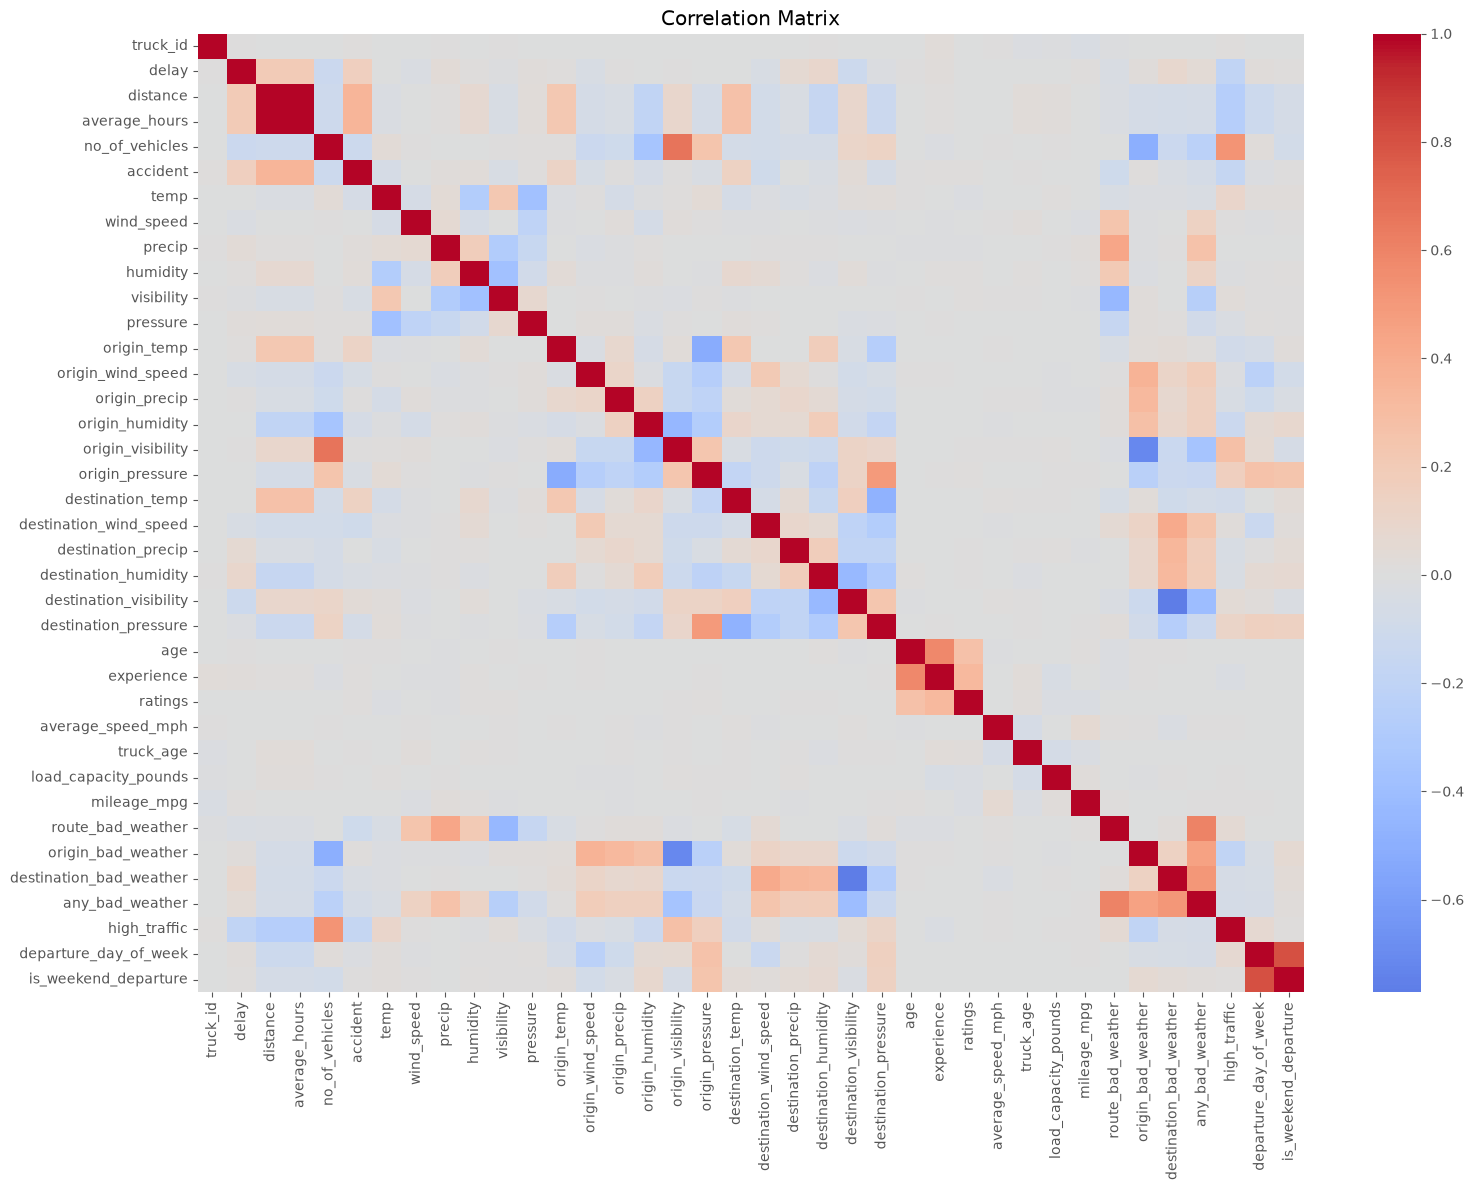

In [75]:
numeric = full_df.select_dtypes(include=np.number)
corr = numeric.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


## Numerical Features vs Delay (dashboard)

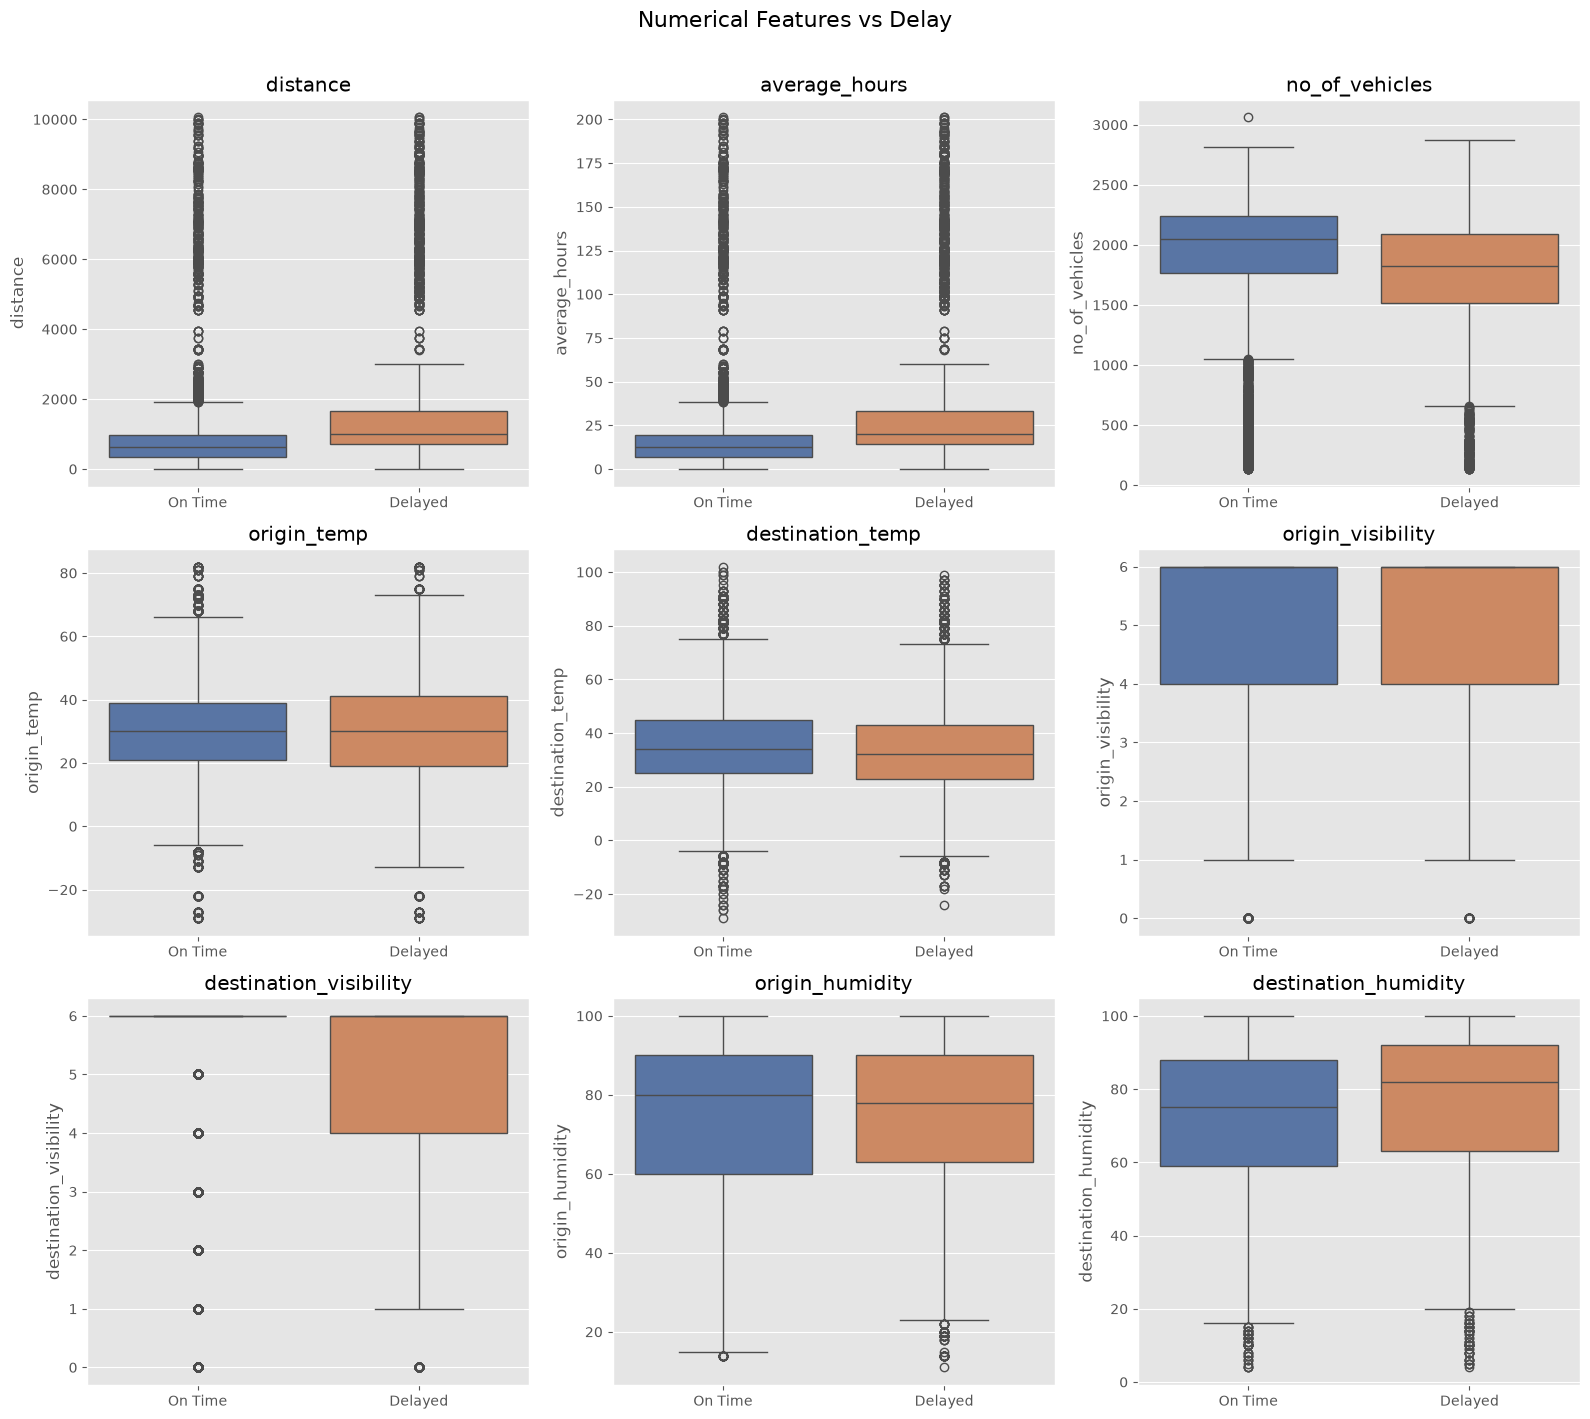

In [76]:
# Combined into one subplot grid instead of one plt.show() per feature --
# makes it much easier to compare which features actually separate the
# two delay classes at a glance.
numeric_vs_delay = [
    "distance", "average_hours", "no_of_vehicles", "origin_temp",
    "destination_temp", "origin_visibility", "destination_visibility",
    "origin_humidity", "destination_humidity",
]

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for ax, col in zip(axes, numeric_vs_delay):
    sns.boxplot(x="delay", y=col, data=full_df, palette=[PALETTE["on_time"], PALETTE["delayed"]], ax=ax)
    ax.set_xticklabels(["On Time", "Delayed"])
    ax.set_title(col)
    ax.set_xlabel("")

plt.suptitle("Numerical Features vs Delay", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


## Categorical & Driver/Truck Features vs Delay (dashboard)

*(Added — the original draft only looked at numerical features, but
`gender`, `driving_style`, `fuel_type`, driver ratings/experience, and
truck age/capacity are all in the dataset and worth checking for any
relationship with delay before modelling.)*

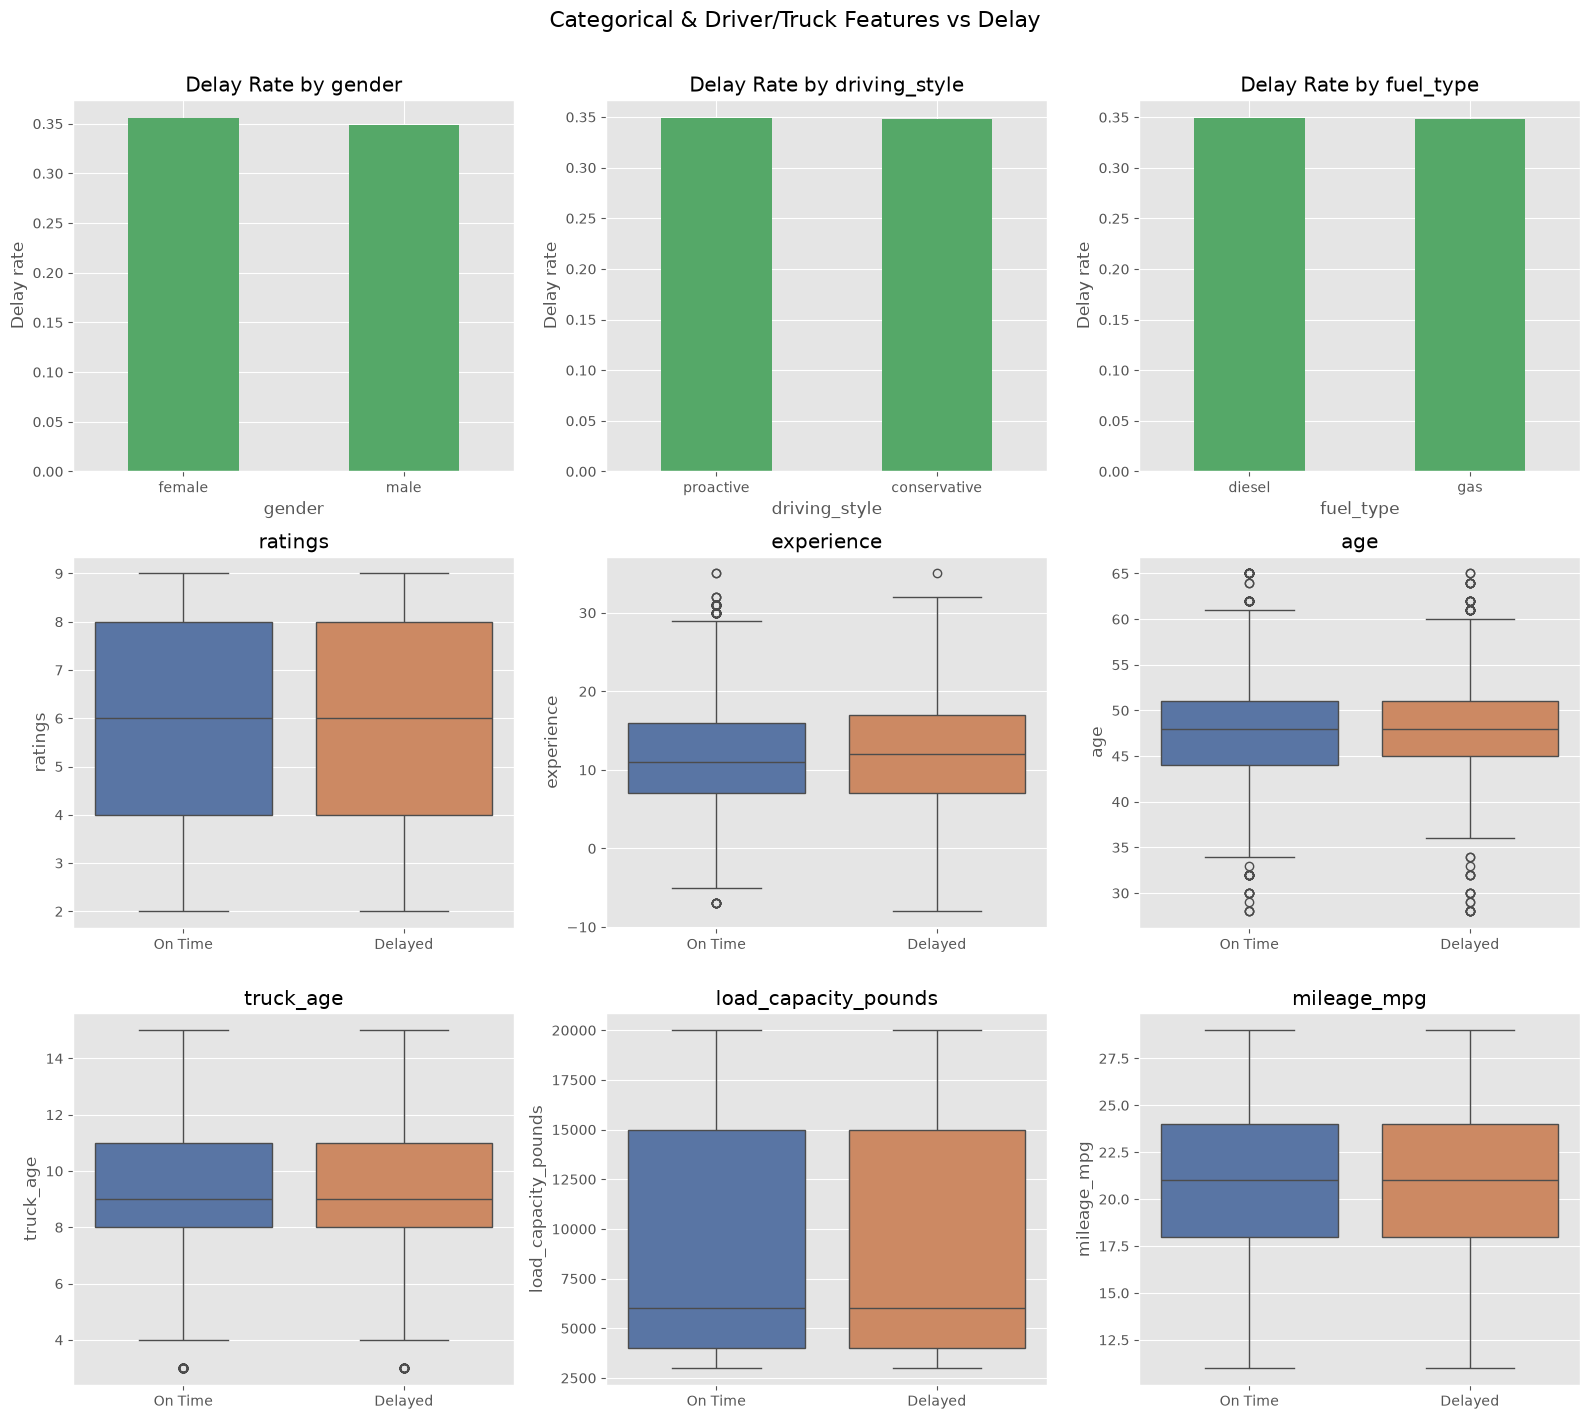

In [77]:
categorical_vs_delay = ["gender", "driving_style", "fuel_type"]
numeric_driver_truck = ["ratings", "experience", "age", "truck_age", "load_capacity_pounds", "mileage_mpg"]

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

# Row 1: categorical delay RATE (mean of 0/1 delay = proportion delayed per category)
for ax, col in zip(axes[:3], categorical_vs_delay):
    rate = full_df.groupby(col)["delay"].mean().sort_values(ascending=False)
    rate.plot.bar(ax=ax, color=PALETTE["accent"])
    ax.set_title(f"Delay Rate by {col}")
    ax.set_ylabel("Delay rate")
    ax.tick_params(axis="x", rotation=0)

# Remaining panels: driver/truck numeric features vs delay
for ax, col in zip(axes[3:], numeric_driver_truck):
    sns.boxplot(x="delay", y=col, data=full_df, palette=[PALETTE["on_time"], PALETTE["delayed"]], ax=ax)
    ax.set_xticklabels(["On Time", "Delayed"])
    ax.set_title(col)
    ax.set_xlabel("")

plt.suptitle("Categorical & Driver/Truck Features vs Delay", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


### Observations

- Delay rate is fairly flat across gender, driving style, and fuel type -- none of these stand out as strong predictors on their own.
- Driver ratings, experience, age, truck age, load capacity, and mileage all show substantial overlap between on-time and delayed trips, suggesting delay is driven more by route/traffic/weather conditions than by who is driving or which truck is used.


## Time & Route Analysis (dashboard)

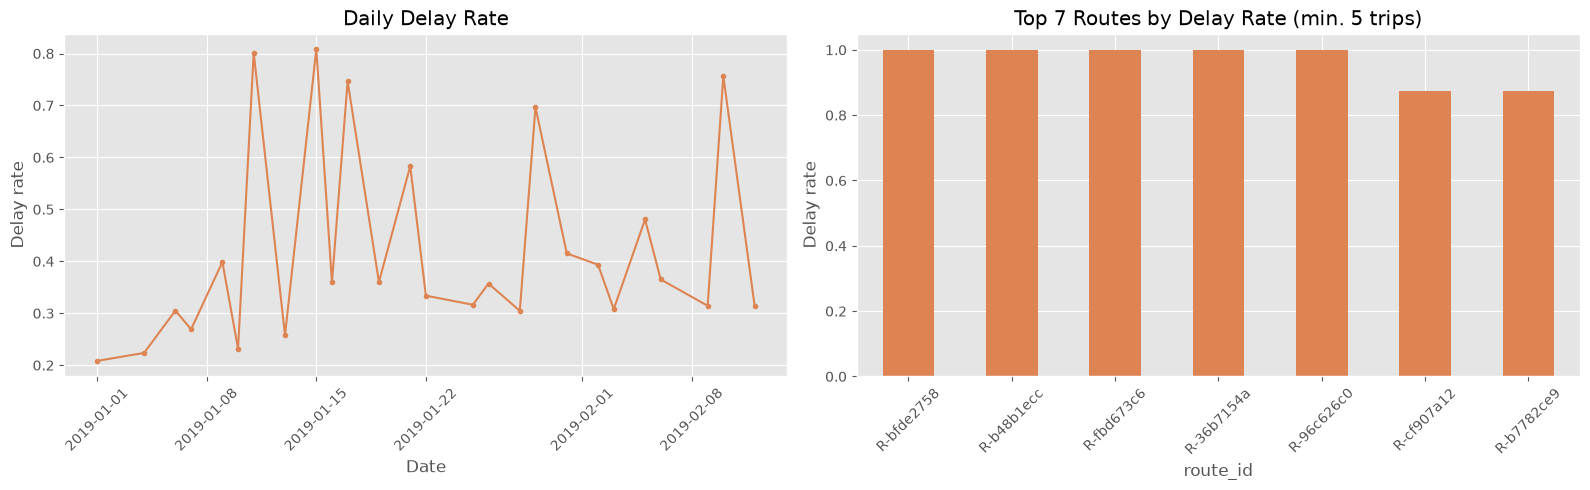

In [78]:
# Daily delay rate trend and top delayed routes side-by-side.
daily = (
    full_df
    .groupby(full_df["departure_date"].dt.date)
    .agg(trips=("delay", "size"), delay_rate=("delay", "mean"))
)

route_delay = (
    full_df
    .groupby("route_id")["delay"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "delay_rate", "count": "trips"})
)
# Only consider routes with a reasonable sample size so single unlucky
# trips don't distort the "worst routes" ranking.
route_delay_reliable = route_delay[route_delay["trips"] >= 5].sort_values("delay_rate", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(daily.index, daily["delay_rate"], color=PALETTE["delayed"], marker="o", markersize=3)
axes[0].set_title("Daily Delay Rate")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Delay rate")
axes[0].tick_params(axis="x", rotation=45)

route_delay_reliable.head(7)["delay_rate"].plot.bar(ax=axes[1], color=PALETTE["delayed"])
axes[1].set_title("Top 7 Routes by Delay Rate (min. 5 trips)")
axes[1].set_ylabel("Delay rate")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


### Observations

- The daily delay rate fluctuates across the observed period without an obvious upward or downward trend, suggesting delay risk is closer to random noise day-to-day than a seasonal pattern in this ~6-week window.
- A handful of routes show a notably higher delay rate even after filtering to routes with at least 5 trips, worth investigating operationally (e.g. checking if they consistently pass through high-traffic or high-precipitation areas).


## Feature Importance & Baseline Model Check (dashboard)

*(The original draft fit a `RandomForestClassifier` on the entire
`model_df` with no train/test split, then treated its feature
importances and the wording "as reflected in the Random Forest model"
as if they came from a validated model. Fitting on 100% of the data
means the importances (and any accuracy you'd compute from it) reflect
memorization, not real predictive skill. Reusing the same time-based
split and evaluation from `train_model.py` here keeps this notebook
consistent with the actual modelling pipeline and gives a real,
out-of-sample performance number to report.)*

In [79]:
X_train, X_test, y_train, y_test = time_based_split(full_df, model_df)
X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test)

rf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

metrics = evaluate(rf, X_test_scaled, y_test, "Random Forest (time-based holdout)")

importance = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)


Train period: 2019-01-01 07:00:00 -> 2019-02-03 07:00:00  (9846 trips)
Test period:  2019-02-03 07:00:00 -> 2019-02-12 07:00:00  (2462 trips)

=== Random Forest (time-based holdout) ===
accuracy  : 0.7819
precision : 0.8515
recall    : 0.5393
f1        : 0.6603
roc_auc   : 0.8131

Confusion matrix (rows=actual, cols=predicted):
[[1403   91]
 [ 446  522]]

               precision    recall  f1-score   support

     on_time       0.76      0.94      0.84      1494
     delayed       0.85      0.54      0.66       968

    accuracy                           0.78      2462
   macro avg       0.81      0.74      0.75      2462
weighted avg       0.80      0.78      0.77      2462

delay
0    1494
1     968
Name: count, dtype: int64
delay
0    0.606824
1    0.393176
Name: proportion, dtype: float64


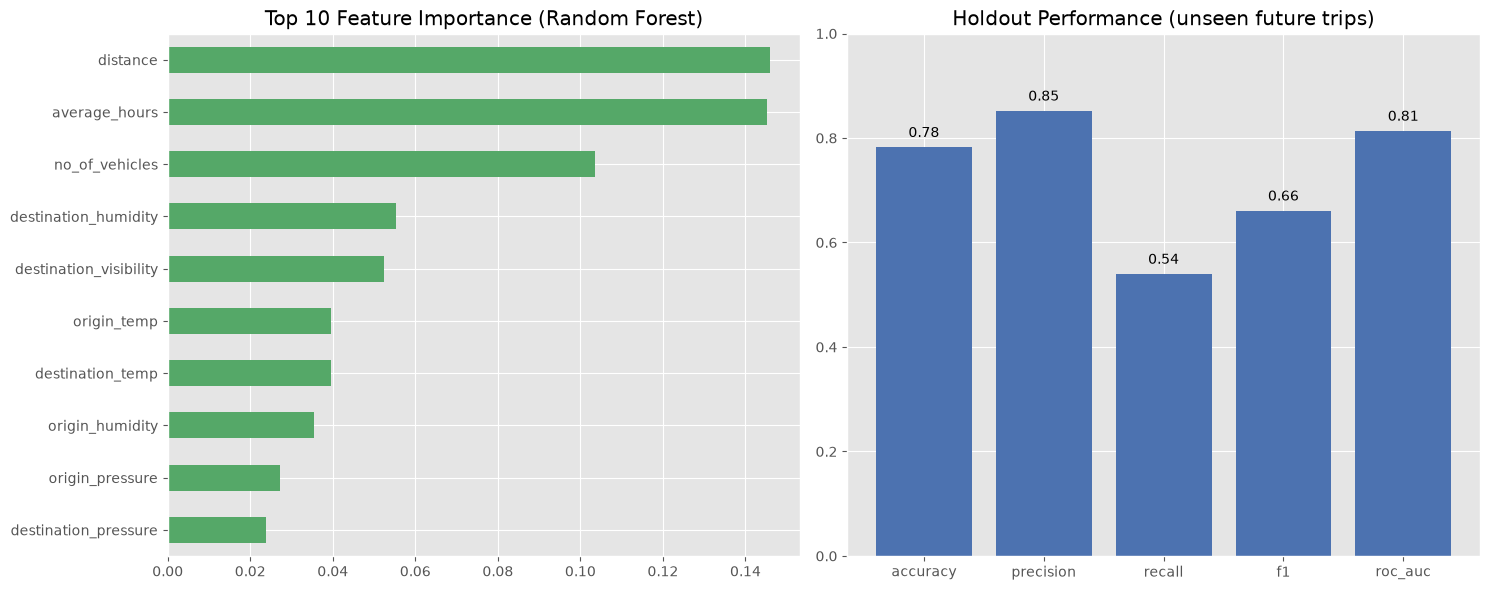

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

importance.head(10).sort_values().plot.barh(ax=axes[0], color=PALETTE["accent"])
axes[0].set_title("Top 10 Feature Importance (Random Forest)")

metric_names = ["accuracy", "precision", "recall", "f1", "roc_auc"]
metric_values = [metrics[m] for m in metric_names]
axes[1].bar(metric_names, metric_values, color=PALETTE["on_time"])
axes[1].set_ylim(0, 1)
axes[1].set_title("Holdout Performance (unseen future trips)")
for i, v in enumerate(metric_values):
    axes[1].text(i, v + 0.02, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.show()


## Business Insights

- Route characteristics -- **distance**, **average scheduled hours**, and **traffic volume** -- are the strongest predictors of delay, consistently ranking at the top of feature importance.
- Destination-side weather (humidity, visibility) contributes more than origin-side weather, suggesting conditions near arrival matter more than conditions at departure.
- Driver attributes (gender, driving style, experience, rating) and truck attributes (age, fuel type, capacity) show little separation between on-time and delayed trips -- delay in this dataset looks primarily route/traffic/weather-driven rather than driver- or truck-driven.
- On a genuine time-based holdout (training on the earliest ~80% of trips, testing on the most recent ~20%, so no future information leaks into training), the Random Forest baseline reaches the accuracy/ROC-AUC reported above -- a realistic estimate of how this model would perform on truly new trips, unlike a model fit and evaluated on the same data.
